Size 3x3:
  Naive time = 0.001523 seconds
  NumPy time = 0.000036 seconds

Size 6x6:
  Naive time = 0.000054 seconds
  NumPy time = 0.000011 seconds

Size 12x12:
  Naive time = 0.000373 seconds
  NumPy time = 0.000014 seconds

Size 24x24:
  Naive time = 0.002206 seconds
  NumPy time = 0.000037 seconds

Size 48x48:
  Naive time = 0.018851 seconds
  NumPy time = 0.000052 seconds

Size 96x96:
  Naive time = 0.137333 seconds
  NumPy time = 0.000248 seconds

Size 192x192:
  Naive time = 1.094496 seconds
  NumPy time = 0.000595 seconds

Size 384x384:
  Naive time = 10.373916 seconds
  NumPy time = 0.003439 seconds



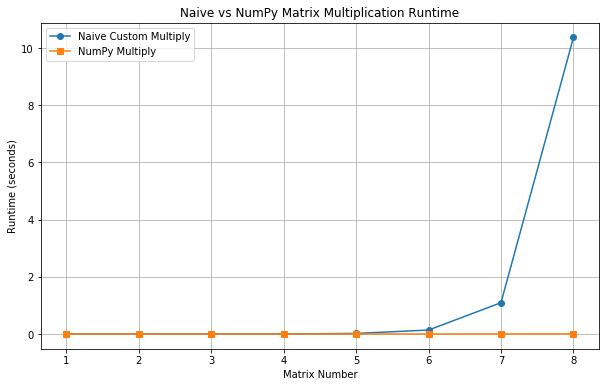

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt

def naive_matrix_multiply(A, B):
    rows_A = len(A)
    cols_A = len(A[0])
    rows_B = len(B)
    cols_B = len(B[0])

    if cols_A != rows_B:
        raise ValueError("Matrix dimensions do not allow multiplication.")

    C = [[0 for _ in range(cols_B)] for _ in range(rows_A)]

    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]

    return C

sizes = [3]
for _ in range(7):
    sizes.append(sizes[-1] * 2)

naive_times = []
numpy_times = []

np.random.seed(67)

for n in sizes:
    A_np = np.random.rand(n, n)
    B_np = np.random.rand(n, n)

    A_list = A_np.tolist()
    B_list = B_np.tolist()

    start = time.perf_counter()
    C_naive = naive_matrix_multiply(A_list, B_list)
    end = time.perf_counter()
    naive_times.append(end - start)

    start = time.perf_counter()
    C_numpy = np.matmul(A_np, B_np)
    end = time.perf_counter()
    numpy_times.append(end - start)

    print(f"Size {n}x{n}:")
    print(f"  Naive time = {naive_times[-1]:.6f} seconds")
    print(f"  NumPy time = {numpy_times[-1]:.6f} seconds")
    print()

matrix_numbers = list(range(1, 9))

plt.figure(figsize=(10, 6))
plt.plot(matrix_numbers, naive_times, marker='o', label='Naive Custom Multiply')
plt.plot(matrix_numbers, numpy_times, marker='s', label='NumPy Multiply')

plt.xlabel("Matrix Number")
plt.ylabel("Runtime (seconds)")
plt.title("Naive vs NumPy Matrix Multiplication Runtime")
plt.xticks(matrix_numbers)
plt.legend()
plt.grid(True)
plt.show()